In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/oladimejiwilliams/energydata-complete/energydata_complete.csv


Dataset originale

→ Lasso selection  (con 0.1 e con 1) (so le variabili 'migliori' da togliere nello studio con random forest: 'Tdewpoint', 'Windspeed','rv1', 'rv2','Press_mm_hg', 'Visibility') <- hanno fatto il modello con risultato migliere con RF

→ Random Forest (100, 200, 500, 1000)
→ XGBoost (100, 200, 500, 1000)
__________________________________________

Dataset PCA: principal component analysis

→ Random Forest

→ XGBoost

→ Confronto finale

In [2]:
df = pd.read_csv("/kaggle/input/datasets/oladimejiwilliams/energydata-complete/energydata_complete.csv",header= 0,encoding= 'unicode_escape')

df['date'] = pd.to_datetime(df['date']) #very important to filter the data by days, months etc

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday      # 0 = Monday, 1 Tuesday etc
df['month'] = df['date'].dt.month


In [3]:
y = df['Appliances'] #dataset only column is appliances
X = df.drop(columns=['Appliances', 'date']) #dataset w/o the columns appliances and date

#1) SCALING
#data scaling means rescaling numerical features so they are on a similar range or scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
#2) SPLIT DATA FOR TEST AND FOR TRAINIG 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=0)

In [5]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lasso1 = Lasso(alpha=0.5) #risultato migliore ma elimina solo la feature T7, Tdewpoint
lasso2 = Lasso(alpha=1) #risultato leggermente peggiore, elimina più feature

lasso1.fit(X_train, y_train)
lasso2.fit(X_train, y_train)

Lasso(alpha=1)

In [6]:
def removed_coeff(model):
    coefficients = pd.Series(model.coef_, index=X.columns)
    zero_coeffs = coefficients[coefficients == 0]

    print(f"\n\nFeatures rimosse da Lasso:\n{zero_coeffs}")

In [7]:
removed_coeff(lasso1)
removed_coeff(lasso2)



Features rimosse da Lasso:
T7           0.0
Tdewpoint    0.0
dtype: float64


Features rimosse da Lasso:
T7            -0.0
Press_mm_hg    0.0
Tdewpoint     -0.0
rv1            0.0
rv2            0.0
day            0.0
dtype: float64


# Creo due db su cui fare test e training con Lasso (per fare feature selection) + Random Forest

In [8]:
df1 = df.drop(columns=['T7', 'Tdewpoint']) #<-- feature rimosse con lasso1
df2 = df.drop(columns=['T7', 'Tdewpoint','Press_mm_hg', 'rv1','rv2', 'day']) #<-- feature rimosse con lasso2

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#DATA SCALING + DATA TESTING AND TRAINING
def prepara_dati(dataframe):

    y = dataframe['Appliances']
    X = dataframe.drop(columns=['Appliances', 'date'])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return train_test_split(
        X_scaled,
        y,
        test_size=0.2,
        random_state=0
    )

In [10]:
X_train, X_test, y_train, y_test = prepara_dati(df1)

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

def eval_model(model):
    preds = model.predict(X_test)
    print("MAE :", mean_absolute_error(y_test, preds)) #average absolute difference between your model’s predictions and the actual values.
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds))) #average of squared differences between predictions and actual values->emphasizes big errors
    print("R²  :", r2_score(y_test, preds)) #how well the model’s predictions match the actual data. 1=perfect fit, <0=bad 
    print("\n")

# Primo dataset: df1

In [12]:
for n in [100, 200, 500, 1000]:

    print(f"\nRandom Forest with {n} trees")

    rf = RandomForestRegressor(
        n_estimators=n,
        max_depth=15,
        random_state=0
    )

    rf.fit(X_train, y_train)

    eval_model(rf)


Random Forest with 100 trees
MAE : 37.406879581428626
RMSE: 77.88834882693315
R²  : 0.46747299449095614



Random Forest with 200 trees
MAE : 37.25544499390965
RMSE: 77.63976001963879
R²  : 0.4708668012010483



Random Forest with 500 trees
MAE : 37.235733549299276
RMSE: 77.58821157520529
R²  : 0.4715691974584486



Random Forest with 1000 trees
MAE : 37.32135113040482
RMSE: 77.75568592293754
R²  : 0.4692854970249145




# Secondo dataset: df2

In [13]:
X_train, X_test, y_train, y_test = prepara_dati(df2)

In [14]:
for n in [100, 200, 500]:

    print(f"\nRandom Forest with {n} trees")

    rf2 = RandomForestRegressor(
        n_estimators=n,
        max_depth=15,
        random_state=0
    )

    rf2.fit(X_train, y_train)

    eval_model(rf2)


Random Forest with 100 trees
MAE : 37.44237236519952
RMSE: 78.21263125279344
R²  : 0.4630294893688096



Random Forest with 200 trees
MAE : 37.062129338835156
RMSE: 77.67932306379582
R²  : 0.4703274009292293



Random Forest with 500 trees
MAE : 37.05915833892952
RMSE: 77.78386389572148
R²  : 0.4689007748447902




# Conclusione (Lasso + RF )
*  ------> il dataset migliore è stato **df1** cioè quello che mantiene più dati 
* Con **500** alberi
* Mean squared error : 37.23
* root mean squared error : 77.58
* **R² : 0.471**
_______________

# XGBoost 
significa: **Extreme Gradient Boosting**

È un algoritmo basato su: **Decision Trees + Boosting**

Non crea un solo modello, ma molti alberi piccoli.
**Ogni nuovo albero corregge gli errori del precedente**

* Tree 1 → predizione iniziale
* Tree 2 → corregge errori
* Tree 3 → corregge ancora
...
* **Final prediction = somma di tutti gli alberi**

Utilizzare XGBoost sembra una scelta migliore perchè nel dataset ho variabili correlate, relazioni non lineari, cioè ho relazioni complesse che può interpretare meglio di Lasso 

In [15]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [16]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/oladimejiwilliams/energydata-complete/energydata_complete.csv",header= 0,encoding= 'unicode_escape')

df['date'] = pd.to_datetime(df['date']) #very important to filter the data by days, months etc
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday      # 0 = Monday, 1 Tuesday etc
df['month'] = df['date'].dt.month

y = df['Appliances'] #dataset only column is appliances
X = df.drop(columns=['Appliances', 'date']) #dataset w/o the columns appliances and date

#1) SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [17]:
for n in [100, 200, 500, 1000, 2000]:

    print(f"\nXGBoost with {n} trees")
    
    xgboost = xgb.XGBRegressor(
    n_estimators=n,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
    )

    # Training
    xgboost.fit(X_train, y_train)

    eval_model(xgboost)


XGBoost with 100 trees
MAE : 37.226722717285156
RMSE: 73.21584234516803
R²  : 0.46432387828826904



XGBoost with 200 trees
MAE : 35.17827606201172
RMSE: 70.00942668111738
R²  : 0.5102152824401855



XGBoost with 500 trees
MAE : 32.51123046875
RMSE: 65.7664361288777
R²  : 0.5677840113639832



XGBoost with 1000 trees
MAE : 31.291412353515625
RMSE: 63.49511315472436
R²  : 0.5971226692199707



XGBoost with 2000 trees
MAE : 30.736156463623047
RMSE: 62.55121534403328
R²  : 0.6090117692947388




# xgboost è più veloce e performa molto meglio
# Lasso + RF - R²: 0.47 (molto lento con 500-1000 alberi) 
# XGBoost - R²: 0.60 (2000 alberi, learning rate:0.1)
# 2000 è il risultato migliore ma fa overfitting?

In [18]:
from sklearn.metrics import mean_squared_error

train_preds = xgboost.predict(X_train)
test_preds = xgboost.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 6.07227253537722
Test RMSE: 62.55121534403328


Questo significa che
* il modello impara molto bene il training
* ma generalizza meno bene sul test

Tipico comportamento di:
* **troppi alberi**
* **oppure alberi troppo profondi**


 **---> diminuisco learning rate**: controlla quanto ogni albero contribuisce
* learning rate piccolo → aggiornamenti piccoli
* learning rate grande → aggiornamenti grandi


In [19]:
for lr in [0.1, 0.05, 0.01]:

    print(f"\nLearning rate: {lr}")

    xgboost = xgb.XGBRegressor(
        n_estimators=2000,
        learning_rate=lr,
        max_depth=6,
        random_state=42
    )

    xgboost.fit(X_train, y_train)

    eval_model(xgboost)


Learning rate: 0.1
MAE : 30.736156463623047
RMSE: 62.55121534403328
R²  : 0.6090117692947388



Learning rate: 0.05
MAE : 31.10050392150879
RMSE: 63.51555581177043
R²  : 0.5968632698059082



Learning rate: 0.01
MAE : 35.389869689941406
RMSE: 70.38052958959956
R²  : 0.5050090551376343




# 0.1 continua performare (poco) meglio di 0.05
# R²  : 0.596 vs R²  : 0.609 (differenza di 0.013)

* Test con diverso numero di alberi e diversi lr (più basso è il lr più alto deve essere il numero di alberi per continuare a dare buoni risultati)

In [20]:
for lr, n in [(0.1, 2000),
              (0.05, 4000),
              (0.01, 8000)]:

    print(f"\nLR={lr}, Trees={n}")

    xgboost = xgb.XGBRegressor(
        n_estimators=n,
        learning_rate=lr,
        max_depth=6,
        random_state=42
    )

    xgboost.fit(X_train, y_train)

    eval_model(xgboost)


LR=0.1, Trees=2000
MAE : 30.736156463623047
RMSE: 62.55121534403328
R²  : 0.6090117692947388



LR=0.05, Trees=4000
MAE : 30.50971031188965
RMSE: 62.5699959607738
R²  : 0.6087769269943237



LR=0.01, Trees=8000
MAE : 31.63189697265625
RMSE: 64.43680285752855
R²  : 0.5850840210914612




**2000, 0.1 ancora il migliore**


# il parametro più importante da testare ora: max_depth

In [21]:
for depth in [3, 4, 5, 6]:

    print(f"\nMax depth: {depth}")

    xgboost = xgb.XGBRegressor(
        n_estimators=2000,
        learning_rate=0.1,
        max_depth=depth,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    xgboost.fit(X_train, y_train)

    eval_model(xgboost)


Max depth: 3
MAE : 36.946842193603516
RMSE: 70.13560038529826
R²  : 0.5084482431411743



Max depth: 4
MAE : 33.342933654785156
RMSE: 64.99960937382625
R²  : 0.577804446220398



Max depth: 5
MAE : 31.986553192138672
RMSE: 63.4366667894789
R²  : 0.597864031791687



Max depth: 6
MAE : 31.044645309448242
RMSE: 62.660629522751364
R²  : 0.6076427698135376




# feature importance di xgboost

In [22]:
importance = pd.Series(
    xgboost.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(10))

month      0.244785
hour       0.126702
weekday    0.055097
T3         0.032880
lights     0.030668
day        0.030318
T9         0.027505
T8         0.027287
T5         0.023861
RH_7       0.023536
dtype: float32


xgboost diversamente dagli altri modelli tiene in considerazione month hour e weekday di più. Capisce che probabilmente c'è una complessa correlazione tra l'uso dell'energia e il mese/giorno/ora.
Per esempio l'uso delle luci ed elettrodomestici durante il giorno e possibilmente energia che viene usata in riscaldamento in mesi invernali. 

_________

# Studio con PCA : principal component analysis

La **PCA (Principal Component Analysis)**, o Analisi delle Componenti Principali, è una tecnica statistica di machine learning non supervisionato utilizzata per ridurre la dimensionalità di grandi set di dati, semplificandoli mantenendo il massimo delle informazioni (varianza). Trasforma molte variabili correlate in un numero minore di variabili non correlate, dette "componenti principali".

In questo dataset variabili come T1,T1,T3...sono molto simili tra loro, pca crea nuove variabili:

* PC1 → combinazione di T1,T2,T3,...
* PC2 combinazione di altre variabili...

PCA risolve il problema di multicollinearità

Essenzialmente PCA prende per esempio 25 feature originali e le trasforma in 10 feature che spiegano il 90% / 95% della varianza.

(95% sarebbe una varianza ottima da prendere)

In [23]:
from sklearn.decomposition import PCA

y = df['Appliances']
X = df.drop(columns=['Appliances', 'date'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit SOLO sul train
X_test_scaled = scaler.transform(X_test)        # transform sul test

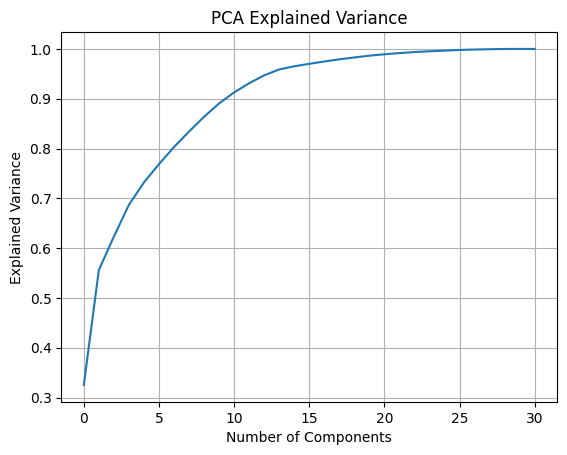

In [25]:
import matplotlib.pyplot as plt
pca = PCA()
X_pca = pca.fit_transform(X_train_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.grid(True)
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

Possiamo dire che il numero di variabili con varianza uguale o maggiore al **95%** è circa 12. 

Possiamo quindi ridurre le 27 variabili originarie in **12 variabili PCA**

In [26]:
pca = PCA(n_components=12)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (19735, 31)
Reduced shape: (19735, 12)


Ogni PC(principal component) è una combinazione lineare delle feature originali.

Vediamo cosa rappresenta ogni componente

In [27]:
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns
)

for i in range(12):  # primi 3 PC
    print(f"\nTop features for PC{i+1}:")

    print(
        loadings.iloc[i]
        .abs()
        .sort_values(ascending=False)
        .head(5)
    )



Top features for PC1:
T9    0.297470
T3    0.290467
T7    0.289704
T4    0.289116
T1    0.287604
Name: 0, dtype: float64

Top features for PC2:
RH_4    0.358246
RH_7    0.350018
RH_3    0.343890
RH_8    0.342226
RH_9    0.338511
Name: 1, dtype: float64

Top features for PC3:
RH_out       0.386924
Windspeed    0.375036
hour         0.370657
rv1          0.311095
rv2          0.311095
Name: 2, dtype: float64

Top features for PC4:
rv2          0.634640
rv1          0.634640
RH_out       0.186943
Windspeed    0.184488
hour         0.181091
Name: 3, dtype: float64

Top features for PC5:
lights     0.576393
hour       0.398020
RH_5       0.367168
weekday    0.262120
day        0.213791
Name: 4, dtype: float64

Top features for PC6:
Press_mm_hg    0.655062
day            0.608606
Windspeed      0.257553
Visibility     0.184710
weekday        0.159183
Name: 5, dtype: float64

Top features for PC7:
weekday       0.679489
Visibility    0.492701
day           0.359447
RH_5          0.282811
hou

In [28]:
pca = PCA().fit(X_scaled)

print(np.cumsum(pca.explained_variance_ratio_)[:12])

[0.32467363 0.55582525 0.62310255 0.68698359 0.73219281 0.76873881
 0.80285353 0.83420961 0.86400685 0.89047175 0.91271928 0.93098622]


# applico PCA con Random Forest

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor

# Target
y = df['Appliances']
# Features
X = df.drop(columns=['Appliances', 'date'])

# 1️ Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 2️ Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
#  3 PCA
pca = PCA(n_components=12)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

def eval_modelPCA(model):
    preds = model.predict(X_test_pca)
    print("MAE :", mean_absolute_error(y_test, preds)) #average absolute difference between your model’s predictions and the actual values.
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds))) #average of squared differences between predictions and actual values->emphasizes big errors
    print("R²  :", r2_score(y_test, preds)) #how well the model’s predictions match the actual data. 1=perfect fit, <0=bad 
    print("\n")

In [32]:
for n in [100, 200, 500]:

    print(f"\nRandom Forest with {n} trees")

    rf = RandomForestRegressor(
        n_estimators=n,
        max_depth=15,
        random_state=0
    )

    rf.fit(X_train_pca, y_train)

    eval_modelPCA(rf)


Random Forest with 100 trees
MAE : 42.481430328877664
RMSE: 80.30562588662735
R²  : 0.3555576252454262



Random Forest with 200 trees
MAE : 42.37071004064387
RMSE: 80.13028463812691
R²  : 0.3583687351465249



Random Forest with 500 trees
MAE : 42.24917656809157
RMSE: 80.02254265245232
R²  : 0.3600930307946305




**Non da buoni risultati**


_____

# **provo con XGBoost :**

In [33]:
for n in [100, 200, 500, 1000, 2000]:

    print(f"\nXGBoost with {n} trees")
    
    xgboost = xgb.XGBRegressor(
    n_estimators=n,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
    )

    # Training
    xgboost.fit(X_train_pca, y_train)

    eval_modelPCA(xgboost)


XGBoost with 100 trees
MAE : 44.24338912963867
RMSE: 81.27439838000187
R²  : 0.3399152159690857



XGBoost with 200 trees
MAE : 42.891754150390625
RMSE: 79.30017080589266
R²  : 0.3715938329696655



XGBoost with 500 trees
MAE : 40.93741989135742
RMSE: 76.7737042232316
R²  : 0.4109974503517151



XGBoost with 1000 trees
MAE : 40.48544692993164
RMSE: 75.99866042713352
R²  : 0.4228295683860779



XGBoost with 2000 trees
MAE : 40.217586517333984
RMSE: 75.76404443855607
R²  : 0.42638760805130005




# CONCLUSIONE FINALE

xgboost con alberi da 1000 a 2000 e un learning rate di 0.05 a 0.1 è il modello migliore. Viene anche testato che diminuendo il learning rate ma aumentando il numero di alberi si ottengono sempre buoni risultati: 

**LR=0.1, Trees=2000 <-- migliore**

MAE : 30.736156463623047

RMSE: 62.55121534403328

R²  : 0.6090117692947388

___________________


LR=0.05, Trees=4000

MAE : 30.50971031188965

RMSE: 62.5699959607738

R²  : 0.6087769269943237

_______________________

LR=0.01, Trees=8000

MAE : 31.63189697265625

RMSE: 64.43680285752855

R²  : 0.5850840210914612

_________________________

Invece Lasso + RF e Lasso + XGboost non danno risultati altrettanto buoni.
il dataset migliore è stato df1 cioè quello che mantiene più dati
Con 500 alberi

Mean squared error : 37.23
root mean squared error : 77.58
R² : 0.471